# Extracting efeatures from NWB files with BluePyEfe

This notebook shows the NWB-specific workflow: inspect an NWB file, read traces through the automatic NWB reader and extract a couple of efeatures.

In [1]:
import os
import pathlib
import tempfile
from pprint import pprint

import h5py
import matplotlib
import numpy as np

matplotlib.use("Agg")
import matplotlib.pyplot as plt

from bluepyefe.cell import Cell
from bluepyefe.reader import inspect_nwb, nwb_reader

The examples can be run either from the repository root or from the `examples` directory.

In [2]:
cwd = pathlib.Path.cwd()
repo_root = cwd.parent if cwd.name == "examples" else cwd

bbp_nwb_path = repo_root / "tests" / "exp_data" / "hippocampus-portal" / "99111002.nwb"

## Inspect the NWB file

`inspect_nwb` chooses the reader class from the file layout and reports the protocols that BluePyEfe can parse.

In [3]:
info = inspect_nwb(bbp_nwb_path)

summary = {
    "reader": info["reader"],
    "protocols": info["protocols"],
    "trace_count": len(info["traces"]),
    "metadata": {
        key: info["metadata"].get(key)
        for key in ("identifier", "nwb_version", "session_description")
    },
}

pprint(summary)

{'metadata': {'identifier': '99111002',
              'nwb_version': '2.4.0',
              'session_description': 'UCL'},
 'protocols': ['Step'],
 'reader': 'BBPNWBReader',
 'trace_count': 16}


## Read and plot the traces

`nwb_reader` returns the raw trace dictionaries that are passed into BluePyEfe recording objects.

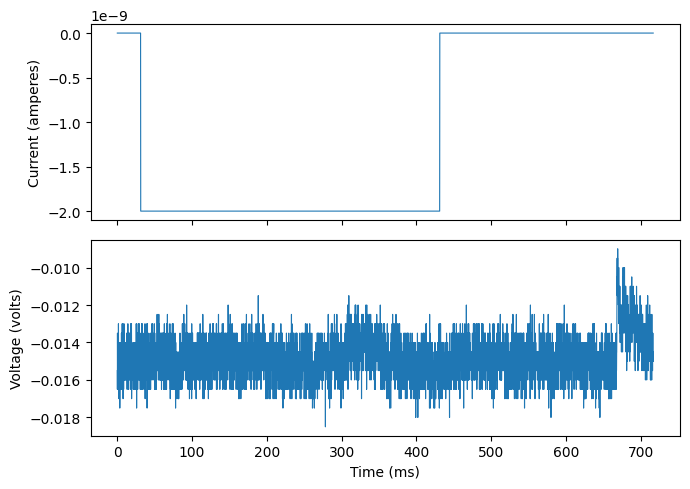

In [4]:
%matplotlib inline
traces = nwb_reader({"filepath": str(bbp_nwb_path), "protocol_name": "Step"})
trace = traces[0]

t_ms = np.arange(trace["voltage"].size) * trace["dt"] * 1000.0

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(7, 5), sharex=True)
axes[0].plot(t_ms, trace["current"], lw=0.8)
axes[0].set_ylabel(f"Current ({trace['i_unit']})")
axes[1].plot(t_ms, trace["voltage"], lw=0.8)
axes[1].set_xlabel("Time (ms)")
axes[1].set_ylabel(f"Voltage ({trace['v_unit']})")

fig.tight_layout()

## Extract efeatures from NWB recordings

A `.nwb` file can be passed to `Cell.read_recordings` with the same `filepath` and `protocol_name` metadata used by `nwb_reader`.

In [5]:
efel_settings = {
    "strict_stiminterval": True,
    "Threshold": -20.0,
    "interp_step": 0.025,
}

cell = Cell(name=bbp_nwb_path)
cell.read_recordings(
    protocol_data=[{"filepath": str(bbp_nwb_path), "protocol_name": "Step"}],
    protocol_name="Step",
    efel_settings=efel_settings,
)

cell.extract_efeatures(
    protocol_name="Step",
    efeatures=["voltage_base", "steady_state_voltage_stimend"],
    efel_settings=efel_settings,
)

first_recording = cell.recordings[0]
feature_preview = {
    "recording_count": len(cell.recordings),
    "first_recording": first_recording.name,
    "ton_ms": float(first_recording.ton),
    "toff_ms": float(first_recording.toff),
    "amp_nA": float(first_recording.amp),
    "efeatures": {
        name: float(value)
        for name, value in first_recording.efeatures.items()
    },
}

pprint(feature_preview)

{'amp_nA': -2.0,
 'efeatures': {'steady_state_voltage_stimend': -15.354062499997845,
               'voltage_base': -14.819999999999457},
 'first_recording': 'ic__Step__1',
 'recording_count': 16,
 'toff_ms': 431.1,
 'ton_ms': 31.200000000000003}
